# Toxic Comment Classification — Preprocessing

## Goal
The goal of this notebook is to clean and prepare toxic comment text data before modeling.

## What this notebook does
- explores raw text
- removes noisy patterns such as URLs, HTML, IP addresses, and Wikipedia-specific artifacts
- normalizes obfuscated profanity
- creates additional text-based numerical features
- prepares train and test data for later modeling

## Why preprocessing matters
Raw comments often contain irrelevant noise and inconsistent writing styles.  
Preprocessing helps make the data cleaner, more informative, and easier for machine learning models to learn from.

In [1]:
# Importing libraries
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# loading the data
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")
test_labels_df = pd.read_csv("../data/raw/test_labels.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Test labels shape:", test_labels_df.shape)

Train shape: (159571, 8)
Test shape: (153164, 2)
Test labels shape: (153164, 7)


In [3]:
# Raw data(before)
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


## Raw Text Examples

Before preprocessing, comments may contain:
- URLs
- HTML tags
- Wikipedia formatting artifacts
- obfuscated profanity
- repeated characters
- inconsistent punctuation and casing

These patterns add noise and make learning harder for the model.

In [4]:
# Ram comment example
sample_raw = train_df["comment_text"].dropna().sample(5, random_state=42).tolist()

for i, text in enumerate(sample_raw, 1):
    print(f"Example {i}:")
    print(text)
    print("-" * 100)

Example 1:
Geez, are you forgetful!  We've already discussed why Marx  was  not an anarchist, i.e. he wanted to use a State to mold his 'socialist man.'  Ergo, he is a statist - the opposite of an  anarchist.  I know a guy who says that, when he gets old and his teeth fall out, he'll quit eating meat.  Would you call him a vegetarian?
----------------------------------------------------------------------------------------------------
Example 2:
Carioca RFA 

Thanks for your support on my request for adminship.

The final outcome was (31/4/1), so I am now an administrator. If you have any comments or concerns on my actions as an administrator, please let me know. Thank you!
----------------------------------------------------------------------------------------------------
Example 3:
"

 Birthday 

No worries, It's what I do ;)Enjoy ur day|talk|e "
----------------------------------------------------------------------------------------------------
Example 4:
Pseudoscience category? 

I'

In [5]:
# Preprocessing functions
lemmatizer = WordNetLemmatizer()

def remove_ip_addresses(text):
    """Remove IP addresses like 192.168.0.1"""
    return re.sub(r'\b(?:\d{1,3}\.){3}\d{1,3}\b', '', text)

def remove_urls(text):
    """Remove URLs"""
    return re.sub(r'http\S+|www\S+', '', text)

def remove_html(text):
    """Remove HTML tags"""
    return re.sub(r'<.*?>', '', text)

def remove_wikipedia_artifacts(text):
    """Remove Wikipedia-specific noise"""
    return re.sub(r'\b(wikipedia|talk|user:).*$', '', text, flags=re.IGNORECASE)

def normalize_profanity(text):
    """Restore obfuscated profanity to consistent form"""
    patterns = {
        r'f[\W_]*u[\W_]*c[\W_]*k+': 'fuck',
        r's[\W_]*h[\W_]*i[\W_]*t+': 'shit',
        r'b[\W_]*i[\W_]*t[\W_]*c[\W_]*h+': 'bitch',
        r'a[\W_]*s[\W_]*s+': 'ass',
        r'd[\W_]*i[\W_]*c[\W_]*k+': 'dick',
        r'p[\W_]*u[\W_]*s[\W_]*s[\W_]*y+': 'pussy',
        r'c[\W_]*u[\W_]*n[\W_]*t+': 'cunt',
        r'n[\W_]*i[\W_]*g[\W_]*g[\W_]*e[\W_]*r+': 'nigger',
        r'f[\W_]*a[\W_]*g+': 'fag',
        r's[\W_]*l[\W_]*u[\W_]*t+': 'slut',
        r'w[\W_]*h[\W_]*o[\W_]*r[\W_]*e+': 'whore',
        r'b[\W_]*a[\W_]*s[\W_]*t[\W_]*a[\W_]*r[\W_]*d+': 'bastard'
    }
    for pattern, replacement in patterns.items():
        text = re.sub(pattern, replacement, text)
    return text

def normalize_repeated_chars(text):
    """Reduce repeated characters like loooool -> loool"""
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

def remove_non_ascii(text):
    """Remove emojis and non-ASCII characters"""
    return text.encode('ascii', 'ignore').decode()

def remove_numbers(text):
    """Remove numbers"""
    return re.sub(r'\d+', '', text)

def clean_punctuation(text):
    """Remove punctuation except ! and ?"""
    return re.sub(r'[^\w\s!?]', '', text)

def remove_extra_spaces(text):
    """Remove extra whitespace"""
    return re.sub(r'\s+', ' ', text).strip()

def remove_stopwords(text):
    """Remove common English stopwords"""
    return " ".join([w for w in text.split() if w not in ENGLISH_STOP_WORDS])

def lemmatize_text(text):
    """Convert words to their base form"""
    return " ".join([lemmatizer.lemmatize(w) for w in text.split()])

def clean_text(text):
    """
    Full text cleaning pipeline:
    - lowercase
    - remove IPs, URLs, HTML, Wikipedia artifacts
    - normalize profanity
    - clean punctuation
    - remove extra spaces
    """
    text = str(text).lower()
    text = remove_ip_addresses(text)
    text = remove_urls(text)
    text = remove_html(text)
    text = remove_wikipedia_artifacts(text)
    text = normalize_profanity(text)
    text = clean_punctuation(text)
    text = remove_extra_spaces(text)
    return text

def add_text_features(df, text_column='comment_text'):
    """
    Add numerical text features
    """
    df = df.copy()
    df['comment_length'] = df[text_column].astype(str).apply(len)
    df['word_count'] = df[text_column].astype(str).apply(lambda x: len(x.split()))
    df['num_exclamation'] = df[text_column].astype(str).apply(lambda x: x.count('!'))
    df['num_question'] = df[text_column].astype(str).apply(lambda x: x.count('?'))
    df['num_uppercase'] = df[text_column].astype(str).apply(lambda x: sum(1 for c in x if c.isupper()))
    return df

def preprocess_train(df, text_column='comment_text'):
    """
    Preprocess training data:
    - extract features before cleaning
    - clean text
    """
    df = add_text_features(df, text_column=text_column)
    df[text_column] = df[text_column].astype(str).apply(clean_text)
    return df

def remove_unlabeled_rows(labels: pd.DataFrame, test: pd.DataFrame):
    """
    Remove rows with -1 labels from test labels and test data
    """
    LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
    mask = (labels[LABELS] == -1).any(axis=1)
    return labels[~mask].reset_index(drop=True), test[~mask].reset_index(drop=True)

def preprocess_test(test, labels, text_column='comment_text'):
    """
    Preprocess test data
    """
    labels_cleaned, test_cleaned = remove_unlabeled_rows(labels, test)
    test_cleaned = add_text_features(test_cleaned, text_column=text_column)
    test_cleaned[text_column] = test_cleaned[text_column].astype(str).apply(clean_text)
    return test_cleaned, labels_cleaned

In [6]:
# before/after examples
demo_samples = train_df["comment_text"].dropna().sample(5, random_state=1).tolist()

for i, text in enumerate(demo_samples, 1):
    print(f"Original {i}:")
    print(text)
    print()
    print(f"Cleaned {i}:")
    print(clean_text(text))
    print("=" * 120)

Original 1:
YOU ARE A FAT, GEEKY PRICK WHO HAS NOTHING TO DO ON A WEEKEND BUT MONITOR WIKIPEDIA. I HOPE YOU SUFFOCATE UNDER YOUR OWN SADNESS.

Cleaned 1:
you are a fat geeky prick who has nothing to do on a weekend but monitor
Original 2:
Agent X2: Basically thanks - with a 'little' more 

(Little has to be a bit more in this case. It just lies in the nature of the matter.)

First: English is not my native language, so I won't correct the article myself. I rely on others to do that for me, based on my suggestions. Again, I am a german dissident and as a man with a technical background, I do not only have years-long experience with most probably driving around a hidden GPS/GSM bug and the consequences of this arrangement. I also have the ability to become aware of it, although I have to rely on many 'strange observations' which after months of further observation and consideration start to make sense, if you explain them the way I have.

I had prepared a comprehensive letter yesterday s

## Why these preprocessing steps were chosen

The cleaning pipeline focuses on removing noise while preserving useful meaning.

### Removed
- IP addresses
- URLs
- HTML tags
- Wikipedia-specific artifacts

### Normalized
- obfuscated profanity such as `f***` into a consistent form
- punctuation noise
- excessive spaces

### Preserved
- exclamation marks and question marks, because they can reflect intensity or aggression

In [7]:
# applying preprocessing
train_clean = preprocess_train(train_df)
test_clean, test_labels_clean = preprocess_test(test_df, test_labels_df)

print("Processed train shape:", train_clean.shape)
print("Processed test shape:", test_clean.shape)
print("Processed test labels shape:", test_labels_clean.shape)

Processed train shape: (159571, 13)
Processed test shape: (63978, 7)
Processed test labels shape: (63978, 7)


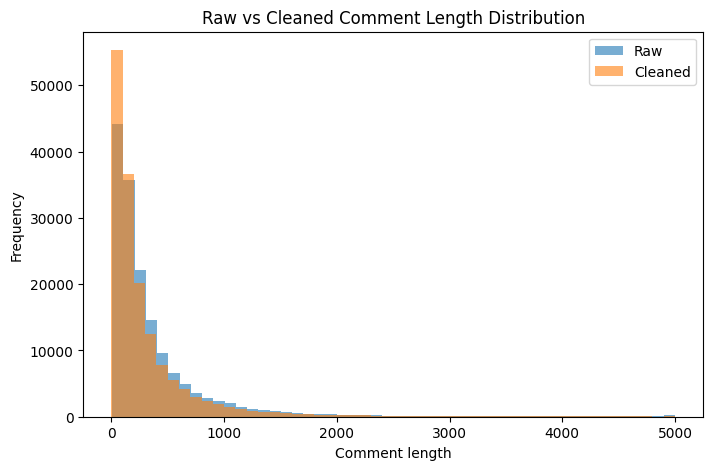

In [8]:
# raw vs cleaned text length
raw_lengths = train_df["comment_text"].astype(str).apply(len)
clean_lengths = train_clean["comment_text"].astype(str).apply(len)

plt.figure(figsize=(8, 5))
plt.hist(raw_lengths, bins=50, alpha=0.6, label="Raw")
plt.hist(clean_lengths, bins=50, alpha=0.6, label="Cleaned")
plt.xlabel("Comment length")
plt.ylabel("Frequency")
plt.title("Raw vs Cleaned Comment Length Distribution")
plt.legend()
plt.show()

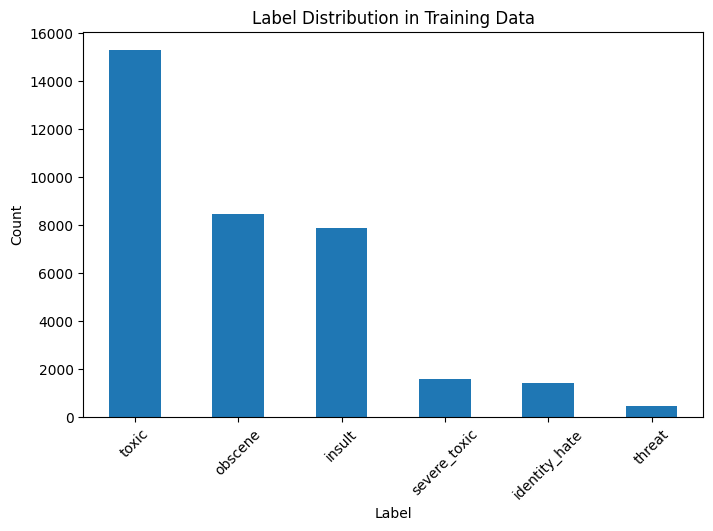

In [9]:
# label distribution
LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
label_counts = train_clean[LABELS].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")
plt.title("Label Distribution in Training Data")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [10]:
# engineered feature distribution
feature_cols = ['comment_length', 'word_count', 'num_exclamation', 'num_question', 'num_uppercase']
train_clean[feature_cols].describe()

,comment_length,word_count,num_exclamation,num_question,num_uppercase
count,159571.000000,159571.000000,159571.000000,159571.00000,159571.000000
mean,394.073221,67.273527,0.661624,0.44928,17.159628
std,590.720282,99.230702,25.899553,1.58990,96.528103
min,6.000000,1.000000,0.000000,0.00000,0.000000
25%,96.000000,17.000000,0.000000,0.00000,3.000000
50%,205.000000,36.000000,0.000000,0.00000,7.000000
75%,435.000000,75.000000,0.000000,1.00000,15.000000
max,5000.000000,1411.000000,4942.000000,209.00000,4960.000000


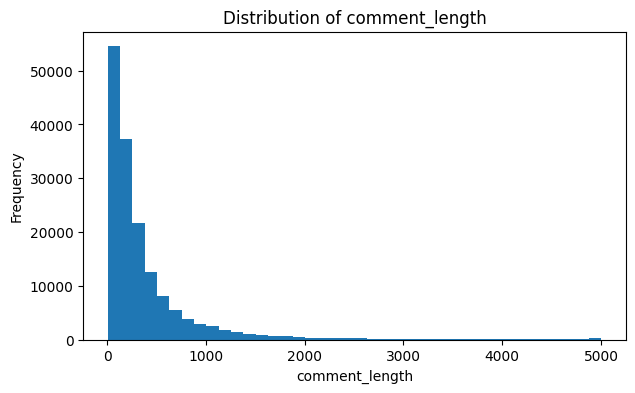

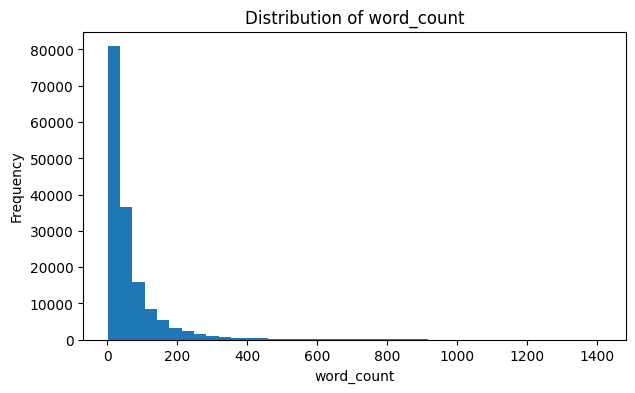

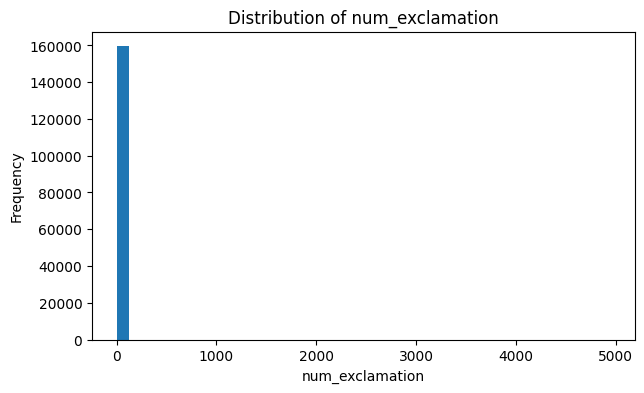

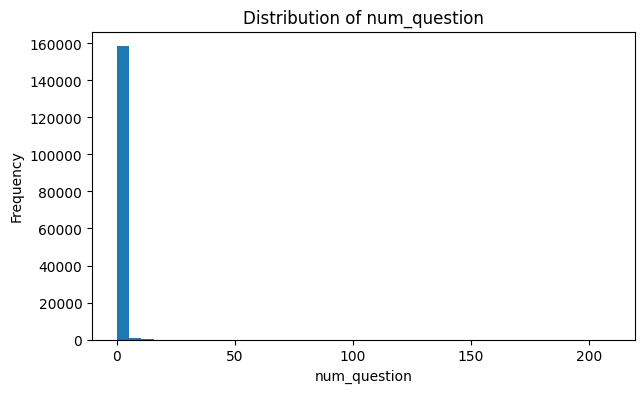

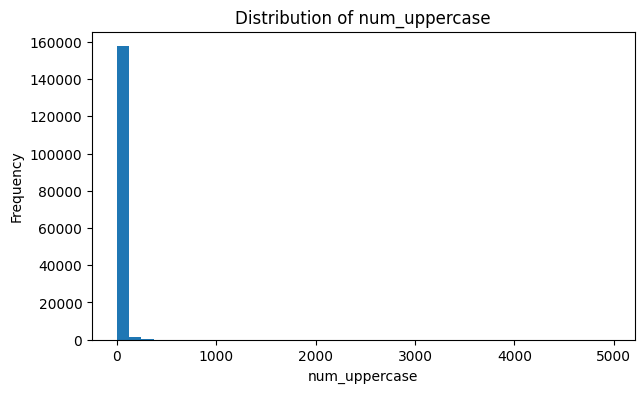

In [11]:
# Visualize engineered features
for col in feature_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(train_clean[col], bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

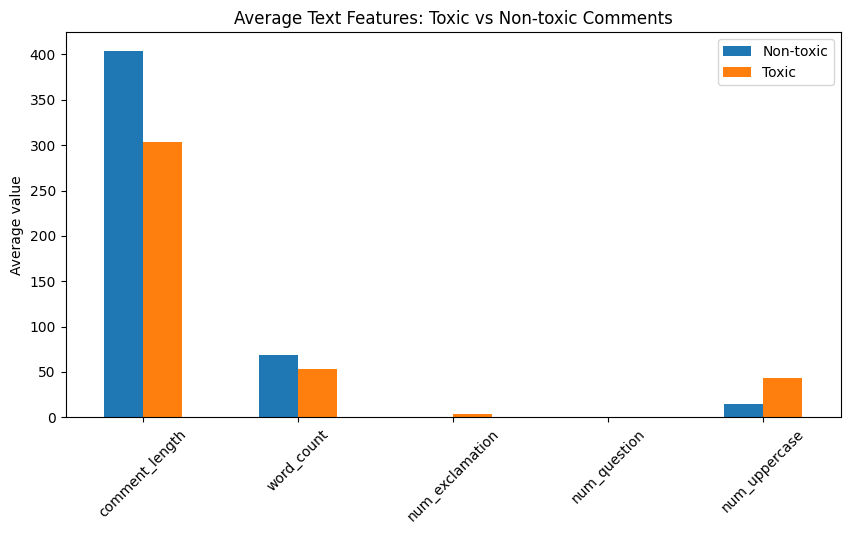

In [12]:
# toxic vs non-toxic comparison
train_clean["is_toxic_any"] = train_clean[LABELS].sum(axis=1).apply(lambda x: 1 if x > 0 else 0)

feature_means = train_clean.groupby("is_toxic_any")[feature_cols].mean().T
feature_means.columns = ["Non-toxic", "Toxic"]

feature_means.plot(kind="bar", figsize=(10, 5))
plt.title("Average Text Features: Toxic vs Non-toxic Comments")
plt.ylabel("Average value")
plt.xticks(rotation=45)
plt.show()

## Interpretation of engineered features

The additional numerical features help capture *how* a comment is written, not only *what* words it contains.

For example:
- `comment_length` may reflect long aggressive messages
- `num_exclamation` may capture emotional intensity
- `num_question` may reflect confrontational style
- `num_uppercase` may indicate shouting or strong emphasis

These features can later complement text-based representations such as TF-IDF.

In [13]:
# save cleaned data
train_clean.to_csv("../data/raw/train_clean.csv", index=False)
test_clean.to_csv("../data/raw/test_clean.csv", index=False)
test_labels_clean.to_csv("../data/raw/test_labels_clean.csv", index=False)

print("Cleaned files saved.")

Cleaned files saved.


# Conclusion

In this notebook, the raw toxic comment data was cleaned and enriched with additional text features.

## Main outcomes
- noisy elements such as URLs, HTML, IP addresses, and Wikipedia artifacts were removed
- obfuscated profanity was normalized
- punctuation-based and style-based numerical features were added
- train and test data were prepared for future modeling

## Why this helps later
This preprocessing stage creates a cleaner and more structured input for future models, whether they are baseline machine learning models or more advanced neural architectures.

In [14]:
summary = pd.DataFrame({
    "Dataset": ["Train", "Test", "Test Labels"],
    "Rows": [len(train_clean), len(test_clean), len(test_labels_clean)],
    "Columns": [train_clean.shape[1], test_clean.shape[1], test_labels_clean.shape[1]]
})

summary

,Dataset,Rows,Columns
0,Train,159571,14
1,Test,63978,7
2,Test Labels,63978,7
